Welcome to Week 3!

We will be focussing in Particle Physics Analysis and detecting matter/antimatter assymetries in the production of certain types of particles.


![LHCb detector](https://www1b.physik.rwth-aachen.de/~schael/LHCb_files/LHCB%20PREVIEW-white-bg.jpg)

The data we are using comes from LHCb - one of the experiments at LHC. It is a highly specialised detector aimed at detecting decays involving the B-quark. Unlike the other major experiments, LHCb detects particles very close to the source and looks almost exclusively in the forward direction - this gives the detector many advantages compared to other experiments at LHC.

In order to get started, we need to access the [ROOT framework](https://root.cern.ch/) through a python package for that - [upROOT](https://pypi.org/project/uproot/) and download some datafiles into your environment!.

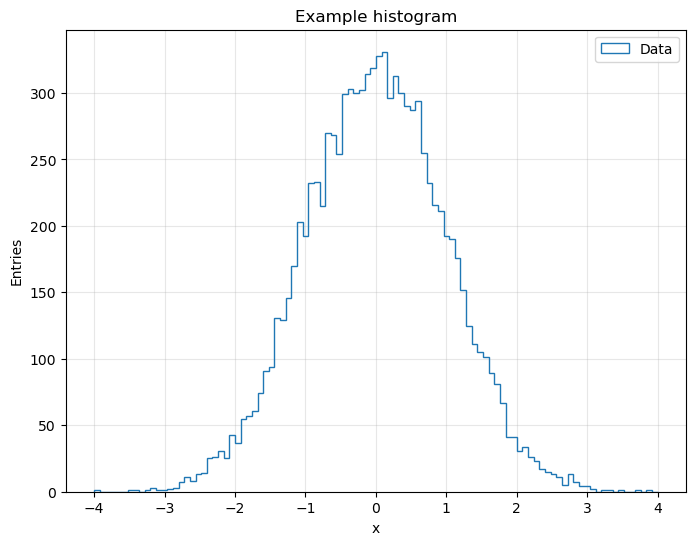

In [1]:
# We use NumPy for numerical work and random numbers
# Matplotlib is used for plotting as before
import numpy as np
import matplotlib.pyplot as plt

# SciPy provides fitting tools, similar to ROOT's Fit("gaus")
from scipy.stats import norm


# ------------------------------------------------------------
# 1. Generate Gaussian-distributed random numbers
#    (equivalent to h.FillRandom("gaus"))
# ------------------------------------------------------------

# Mean (mu) and standard deviation (sigma) of the Gaussian
mu = 0.0
sigma = 1.0

# Number of entries to generate (like number of fills)
n_entries = 10000

# Generate random data
data = np.random.normal(loc=mu, scale=sigma, size=n_entries)


# ------------------------------------------------------------
# 2. Create a histogram (We will do this alot today...))
# ------------------------------------------------------------

# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)


# ------------------------------------------------------------
# 3. Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot
plt.show()



All being well - this should give no errors and we should have some kind of Gaussian distribution above.

We now want to do two things, install uproot - and get our data file from the CERN open data storage location.

This will probably be ratelimited very quickly, so you can find it on Canvas here: https://canvas.maastrichtuniversity.nl/courses/26553/files/6101104?module_item_id=1009080

Then upload it directly.

In [ ]:
!pip install uproot

In [3]:
!mkdir LHCb_Data && cd LHCb_Data && wget http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root

zsh:1: command not found: wget


In [3]:
import uproot

# Open the ROOT file
file = uproot.open("./LHCb_Data/B2HHH_MagnetDown.root")

# List contents (shows us what is inside)
file.keys()

# Access the tree
tree = file["DecayTree"]

# Read one branch as a NumPy array
px = tree["H1_PX"].array(library="np")

# Here we print the information we are being asked with nice labels
print(f'File key: {file.keys()}')
print(f'Tree keys: {tree.keys()}')
print(f'Px branch: {px}')

File key: ['DecayTree;1']
Tree keys: ['B_FlightDistance', 'B_VertexChi2', 'H1_PX', 'H1_PY', 'H1_PZ', 'H1_ProbK', 'H1_ProbPi', 'H1_Charge', 'H1_IPChi2', 'H1_isMuon', 'H2_PX', 'H2_PY', 'H2_PZ', 'H2_ProbK', 'H2_ProbPi', 'H2_Charge', 'H2_IPChi2', 'H2_isMuon', 'H3_PX', 'H3_PY', 'H3_PZ', 'H3_ProbK', 'H3_ProbPi', 'H3_Charge', 'H3_IPChi2', 'H3_isMuon']
Px branch: [  375.2842054  -4985.13078543 -1265.45654435 ...  2606.91083928
  -294.71098895   499.04234923]


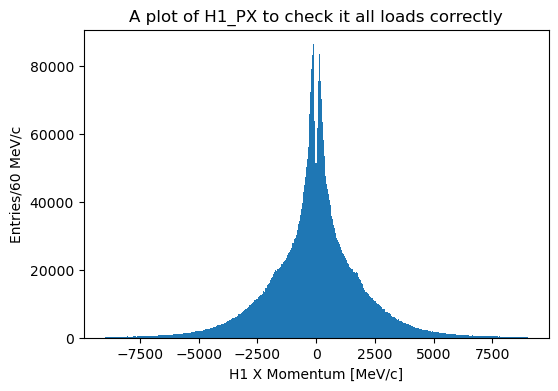

In [4]:
# now our data is an array - we can plot it :)
plt.figure(figsize=(6, 4))


#play with the variables below ...
plt.hist(px, bins=500, range=(-9000, 9000), histtype="bar")
# I found that this range and using 500 bins shows the whole distribution clearly as well as the dip jus in the middle, 
# which wouldn't be visible with a smaller bin count


#Add some labels...

plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.title("A plot of H1_PX to check it all loads correctly")

plt.show()

This is the point at which the setup is all working - you can proceed below if you want to look at a basic guide to fitting functions to data using numpy etc.

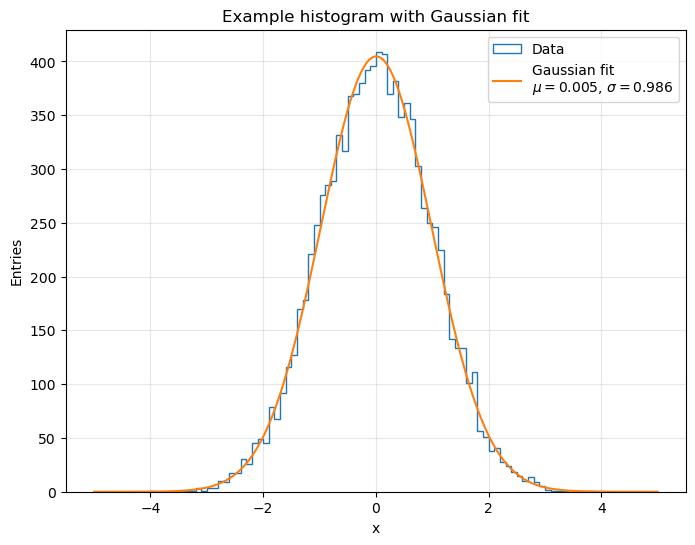

In [5]:
# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -5, 5

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)

# ------------------------------------------------------------
# Now we perform a Gaussian fit
# ------------------------------------------------------------

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu, fit_sigma = norm.fit(data)

# Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

# Evaluate the fitted Gaussian probability density function
pdf = norm.pdf(x, fit_mu, fit_sigma)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width


# ------------------------------------------------------------
# Draw the fitted Gaussian on top of the histogram
# ------------------------------------------------------------

ax.plot(
    x,
    fit_y,
    label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
)


# ------------------------------------------------------------
# labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram with Gaussian fit")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot (equivalent to c.Draw())
plt.show()


## If you are **Here** - and Chris did not make the introduction yet - it's time for a coffee - take a break and wait for instructions about how to proceed.

# Why are we here?

This week is about finding out something about one of the fundemental questions in physics. Why do we have "stuff".

According to many of our models, and according to many measurements in particle physics, matter and anti-matter appear to be produced in equal quantities.

However, when one looks at the Universe in general, we have more matter than anti-matter left - so there need to be some processes where anti-matter and matter are not produced equally. You can find out more about the Matter/Anti-Matter Asymmetry [here](http://press.web.cern.ch/backgrounders/matterantimatter-asymmetry)

One place we look for this asymetry is in [charge-partity (CP) violation](https://www.symmetrymagazine.org/article/october-2005/explain-it-in-60-seconds) in particle physics processes. This essentially says that the processes that happen in the anti-particle version of a decay do not **exactly** match to the processes that happen in the particle version of the decay.



---



At LHCb, we produce both particle of the  B<sup>+</sup> meson and it's antiparticle the B<sup>-</sup> meson.

We cannot detect these mesons directly. They decay into other things before we have a chance to measure them properly. So we collect data on the decay products, often called daughter particles. There are 524 [documented](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) ways that the B<sup>+/-</sup> decays into various combinations. In order to simplify the process, we choose decay combinations that are convenient or have particular properties.

In this analysis, we will take the process:-

B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>


To do so, we are given the following data for each event in our system:-

![alt text](https://raw.githubusercontent.com/lhcb/opendata-project/80d64a3796e593fc8f9b257e85f32ae2e54f131f/Images/Variables.png)

Here, H1 is the detected daughter particle (so a Kaon or a Pion), **not** the B-meson - the mother particle. Normally we would have to do some reconstruction from the decay products (the Daughters) to the Mother to be able to make some conclusions.

Let's get started with working with this data:

For our analysis, the momentum of each of the daughter particles is split into the three cartesian components. We have combined these into a variable called H1_Ptot

In [6]:
# Using Uproot, load your data file and load the variables you think are useful for this analysis - 
# I recommend learning what your data structure is...so plotting and calculations becomes easier later.

f = uproot.open("./LHCb_Data/B2HHH_MagnetDown.root") # we first load the data from the file provided

Events = f['DecayTree'] # we now extract the decay tree from the data so we can analyze the events
Events.show() # we show the contents of the decay tree

# here we set the number of daughters and a list with their names and the labels of each momentum component 
# to facilitate the extraction of infromation with a for loop below
number_of_daughters = 3 
daughter_name = ['H1', 'H2', 'H3'] 
components = ['_PX', '_PY', '_PZ']

# this initializes an empty list where we will store the three momenta of each of the daughter particles for all events
D_P3 = [[0] * 3 for _ in range(number_of_daughters)]

# with a two nested for loops we run through each of the 3 daughter particles and their respective 3 momentum components 
# and store them in a 3 by 3 by "number of events" array
for i in range(number_of_daughters):
    for j in range(3):
        D_P3[i][j] = Events[daughter_name[i] + components[j]].array()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
B_FlightDistance     | double                   | AsDtype('>f8')
B_VertexChi2         | double                   | AsDtype('>f8')
H1_PX                | double                   | AsDtype('>f8')
H1_PY                | double                   | AsDtype('>f8')
H1_PZ                | double                   | AsDtype('>f8')
H1_ProbK             | double                   | AsDtype('>f8')
H1_ProbPi            | double                   | AsDtype('>f8')
H1_Charge            | int32_t                  | AsDtype('>i4')
H1_IPChi2            | double                   | AsDtype('>f8')
H1_isMuon            | int32_t                  | AsDtype('>i4')
H2_PX                | double                   | AsDtype('>f8')
H2_PY                | double                   | AsDtype('>f8')
H2_PZ                | double                   | AsDtype(

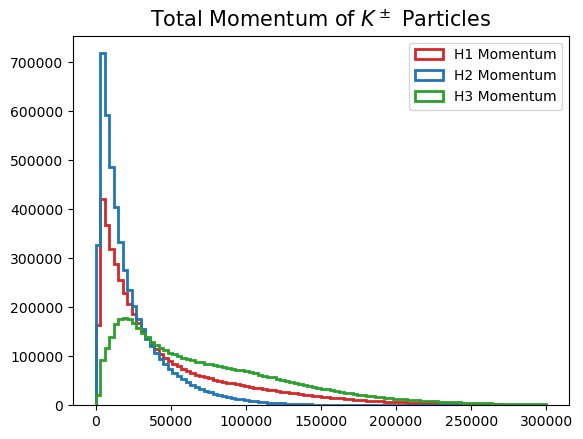

In [7]:
#Here make a plot of the Total momentum of each of the three daughters on one plot

# here we initialize an empty list for the three arrays that will contain the total momenta of each of the three daughter particles 
# in a 3 by number of events array
D_Ptots = [0 for _ in range(number_of_daughters)]
colors = ['tab:red', 'tab:blue', 'tab:green'] # colors to use consistently in the graphs

# here we initialize the figure
plt.figure()
plt.title('Total Momentum of $K^\pm$ Particles', fontsize=15)

# and here we use a for loop to go iterate over the 3 momentum components of each particle, calculating the total momentum with them, 
# and finally ploting said momentum iteratively into the histogram, that way we have a compact and efficient code
for i in range(number_of_daughters):
    D_Ptot = np.sqrt(D_P3[i][0]**2 + D_P3[i][1]**2 + D_P3[i][2]**2)
    D_Ptots[i] = D_Ptot

    plt.hist(D_Ptot, label=daughter_name[i] + ' Momentum', bins=100, range=(0, 300000), color=colors[i], histtype="step", linewidth=2)

plt.legend()
plt.show()

Now plot the total momentum for the mother (M_Ptot) this about how to calculate this from the information available

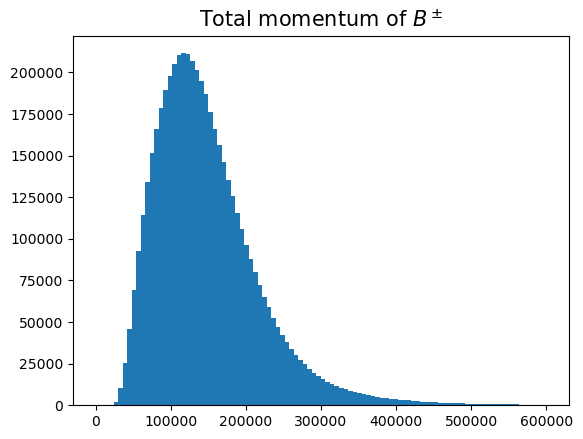

In [8]:
#use the histogram plotting tools, plot the momentum of the mother

# here we initialize a an empty list to hold the 3 momentum components of the mother particle 
M_P = [[0] for _ in range(3)]

# then with two nested for loops we run through each of the 3 daughters and add up the corresponding momentum components
# i.e. all three x components of the daughter particles, all three y components and so on giving us the total x, y and z components of the mother
for i in range(number_of_daughters):   
    for j in range(3):
        M_P[j] = M_P[j] + Events[daughter_name[i] + components[j]].array()

# and finally we simply use pythagorean theorem on the total components to get the magnitude of the total momentum of the mother particles
M_Ptot = np.sqrt(M_P[0]**2 + M_P[1]**2 + M_P[2]**2)

# and plot the distribution of total momentum for the mothers
plt.figure()
plt.hist(M_Ptot, bins=100, range=(0,600000))
plt.title('Total momentum of $B^\pm$', fontsize=15)
plt.show()

Let's take a look at the whole data file that is available to us by looking at one specific entry - for example the number 45th entry in your array...

In [9]:
# print the 45th entry from your array(s) together with the variable name, maybe in a nice list or table.

# we first convert our events into a numpy array so that we can index it and extract the infromation of the 45th event
event_array = Events.arrays(library="np")

print("Event 45")
print("-------------")

# here we just print iteratively of all the items that the event 45 has stored (this is considering that we start with event #0, 
# but since this is just to check the data of an arbitary event I do not think it matters much)
for name, values in event_array.items():
    print(f"{name} :  {values[45]}")

Event 45
-------------
B_FlightDistance :  257.00205776946603
B_VertexChi2 :  1.865567179221614
H1_PX :  420.3413896413646
H1_PY :  -110.66276079201207
H1_PZ :  5883.766388082404
H1_ProbK :  0.012183159589767456
H1_ProbPi :  0.8191394209861755
H1_Charge :  -1
H1_IPChi2 :  27121.53690741779
H1_isMuon :  1
H2_PX :  -985.6367588987478
H2_PY :  630.9893539299605
H2_PZ :  35342.13861801284
H2_ProbK :  0.6670113801956177
H2_ProbPi :  0.04563945531845093
H2_Charge :  1
H2_IPChi2 :  13712.438218214942
H2_isMuon :  0
H3_PX :  -6242.300384410311
H3_PY :  -862.2130979651508
H3_PZ :  277275.49225626234
H3_ProbK :  0.07501816749572754
H3_ProbPi :  0.428352952003479
H3_Charge :  1
H3_IPChi2 :  1026.12298434195
H3_isMuon :  0


We have now completed the initial steps and begun to work through what we need to with the data. This is a perfect moment to take a coffee!

Having discovered all of the relevant information about our daughter particles, we need to combine the measurements about them into a single mother - which will be our B<sup>+</sup> or our B<sup>-</sup>

Having found our momentum and energy, we can use these quantities to find our experimental mass (not the theoretical mass as we have used for the reconstruction).

When we calculate this, we will get a distribution of masses. This is due to errors in the measurements made either by the detector, or in the experiment itself. We hope to have a reasonably narrow peak to work with, but, sometimes this is not possible.

Additionally there will be other particles in the detector - which means our daughters might have come from two or even three different processes. Events which don't come from the same process will give a higher or lower mass than we are looking for. This is typically called the *background* while events which come from our event of interest are called the *signal*

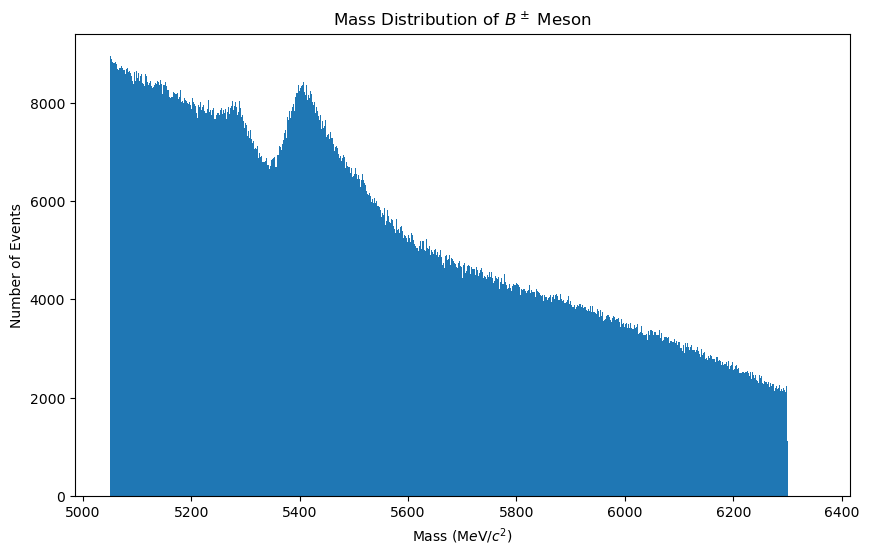

In [10]:
#First find the energy (you might have to do some physics thinking here)

# The using the total momentum find the reconstructed mass of the B

# Now write your new variables to an array

#Now plot a histogram of the range of masses of the B meson.

#Does this match what we would expect from theory?

#What are the features of your plot that you see?

#nwe use the PDG to set the mass of the kaons, looking at K+ since it is the lightest kaon, so we are being generous to have a lower bound
m_k = 493.667 #MeV

# we initialize an empty list to stor the enregy of each of the 3 daughter particles
D_Energies = [[0] for _ in range(number_of_daughters)]

# we use a for loop to cacluate said energies with the formula for relativistic energy √p**2 + m**2
for i in range(number_of_daughters):
    D_Energies[i] = np.sqrt(D_Ptots[i]**2 + m_k**2 )

# then we initialize an empty list to store the total energy of the mother, 
# since conservation of energy dictates that the sum of the daughter energies will be the mother's energy
M_Energy = [0]
for i in range(number_of_daughters):
    M_Energy = M_Energy + D_Energies[i]

# and finally we calculate the relativistic rest mass of the mother with the formula √E**2 - p**2, 
# since we have experimentally determined the total momentum p, 
# and estimated the total energy from a hypothesis that all the daughters are K+
m_B = np.sqrt(M_Energy**2 -M_Ptot**2)

# and we plot the distribution of masses, where, as expected, we see a peak above the background around where the mass of the mother is
plt.figure(figsize=(10, 6))
plt.hist(m_B, bins=1000, range=(5050, 6350))
plt.title('Mass Distribution of $B^\pm$ Meson')
plt.xlabel('Mass $(\mathrm{M}e\mathrm{V}/c^2)$')
plt.ylabel('Number of Events')
plt.show()

# the B+/- mass is 5279,29±0,15 MeV/c**2, and we can see that here we predict a mass of around 5450 MeV/c**2, 
# so we are clearly overestimating it.
# this is most likely because we are taking in particles that do not come from a B+/- decay 
# or that are not kaons, such as pions, as the daughters, which is contributing extra to the mass.

We know that some of our particles are the B+ and some are the B- particle. There will also be some particles in our system that are not coming from a genuine B+/- or are a B+/- but are not constructed from Kaons.

We have some tools available to help:-

  *  During detection, software attributes the probability of a particle being a Kaon or a Pion (in the H1_ProbK or H1_ProbPi variable)
  * The detector also knows if the particle was a Muon - since it has detectors specifically for these. So it can attribute a 0 or a 1 to this probability
  * The reconstructed vertex has a some kind of quality associated with it (we call this the Vertex χ2 (this is the variable B_VertexChi2). This is the statistical measure that determines how well we found a single point to be the source of all three particles.



In order to get a better result, we should select our data to have the properties we desire and make some rules (often called a selection) to cut away data we don't want to include for various reasons. e.g. we know we don't have any muons in our decay - so any time H1/H2/H3 are a muon they should be excluded. The other variables are not so clear - so we can plot them to make a decision.

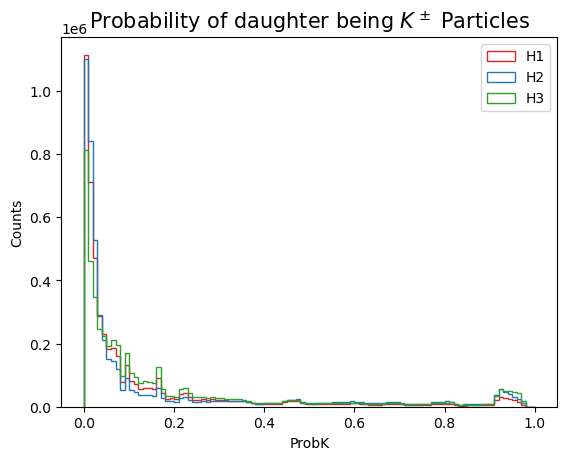

In [11]:
# we initialize the figure over which we will plot the probability of particles being a K+/-
plt.figure()
plt.title('Probability of daughter being $K^\pm$ Particles', fontsize=15)

# we initialize an empty list to hold the probabilities of each respective daughter (H1, H2, and H3)
k_probs = [[0] for _ in range(number_of_daughters)]

# using a for loop we extract the counts for each probability from events as k_prob and turn them into a np array so that we can plot them
# and set one of the three indexes of the k_probs corresponding to the daughter (H1:0, H2:1, H3:2)
# and finally plot the histogram ranging from 0 to 1 of how many of our daughter particles have a certain probability to be a kaon
for i in range(number_of_daughters):
    k_prob = Events[daughter_name[i] + '_ProbK'].array(library="np")
    k_probs[i] = k_prob
    plt.hist(k_prob, label=daughter_name[i], bins=100, range=(0, 1), color=colors[i], histtype="step", linewidth=1) 
    # we set a sensibe binning of 100 since we only want this information to estimate where to put the cutoff to filter the data

plt.xlabel('ProbK')
plt.ylabel('Counts')
plt.legend()
plt.show()


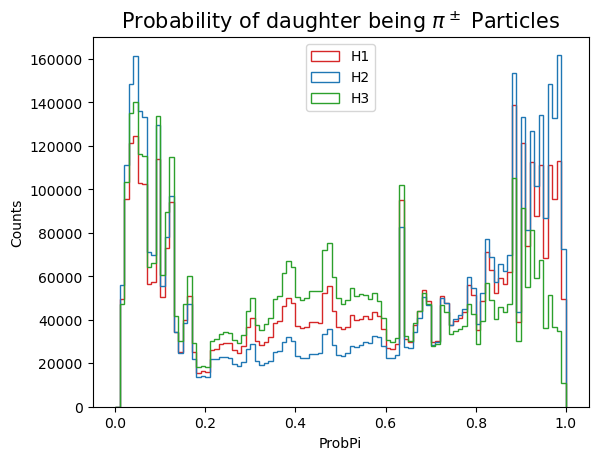

In [13]:
# Do the same for the Probability of being a Pion. Do these distributions match expectations?
plt.figure()
plt.title('Probability of daughter being $\pi^\pm$ Particles', fontsize=15)

# as the instructions say, we repete the exact same process as before, but for the counts of each probability of the dughter particles being pions
# we again initialize the empty lsit to hold each of the three daughter's probability distributions
pi_probs = [[0] for _ in range(number_of_daughters)]

# and we iterate extracting them and storing them in the list we initialized
for i in range(number_of_daughters):
    pi_prob = Events[daughter_name[i] + '_ProbPi'].array(library="np")
    pi_probs[i]= pi_prob
    plt.hist(pi_prob, label=daughter_name[i], bins=100, range=(0, 1), color=colors[i], histtype="step", linewidth=1)

plt.xlabel('ProbPi')
plt.ylabel('Counts')
plt.legend()
plt.show()

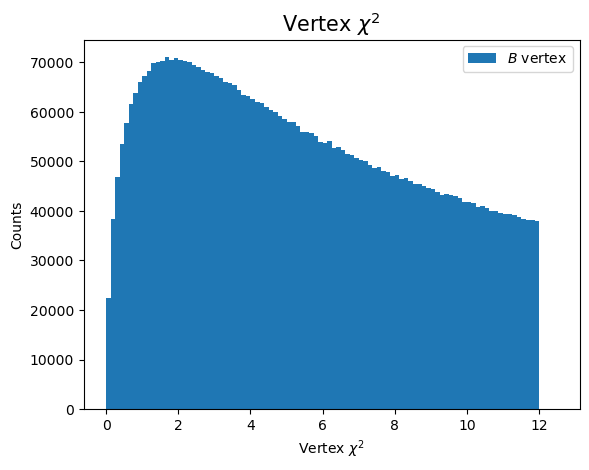

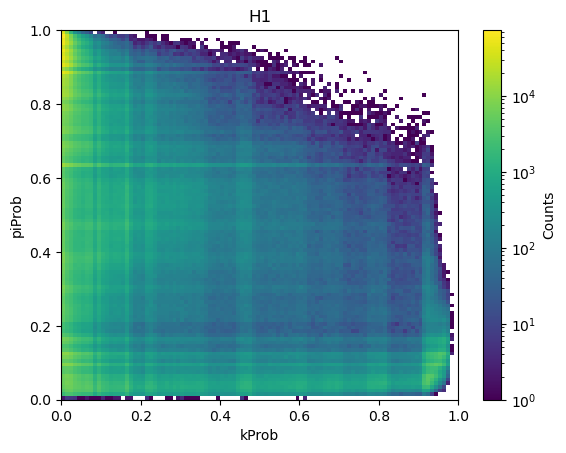

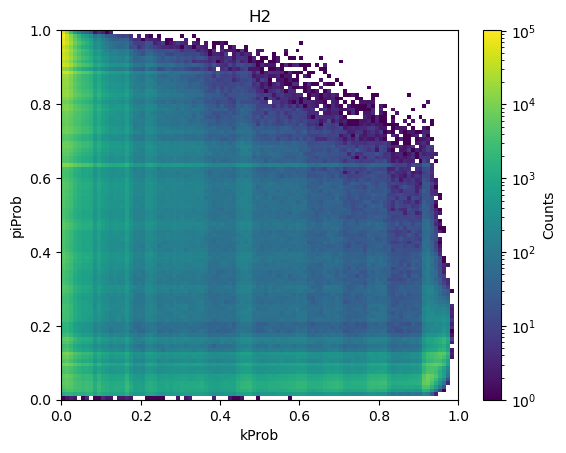

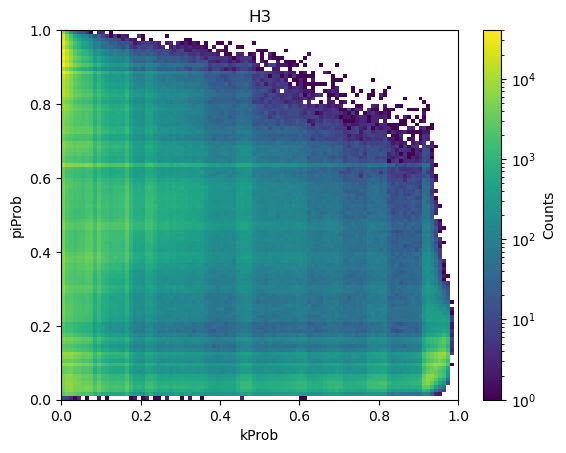

In [14]:
#For all our particles, make a plot of the B_VertexChi2

plt.figure()
plt.title(r'Vertex $\chi^2$', fontsize=15)

# we extract the chi2 vertex for all our particles to see how confident we are that the daughters are in fact coming from the same mother
chi2 = Events['B_VertexChi2'].array(library="np")

# and we plot a histogram ranging from 0 to 12.5 with 12 bing the lest confident and 0 the most confident
plt.hist(chi2, bins=100, range=(0, 12.5), label=r'$B$ vertex')

plt.xlabel(r'Vertex $\chi^2$')
plt.ylabel('Counts')
plt.legend()
plt.show()


#Feeling ambitious? Maybe make a 2d plot of Kaon and Pion Prob in a 2 dimensional analysis?

# I was in fact feeling ambitious so I ploted a 2D histogram using both probabilities that we had already computed, 
# and iterating over all three daughters to get one heat map for each
# the white boxes are those for which we have not particle that matches that pi and k probability, 
# this helps us estimate the probabilities we should use as a cut off and how much of the sample we are confident is akaon and only a kaon

from matplotlib.colors import LogNorm

for i in range(number_of_daughters):
    plt.figure()
    plt.title(daughter_name[i])
    plt.hist2d(k_probs[i], pi_probs[i], bins=100, range=[[0,1],[0,1]], norm=LogNorm())
    plt.xlabel(r'kProb')
    plt.ylabel(r'piProb')
    plt.colorbar(label='Counts')
    plt.show()



Using these plots, we can now make a preselection string. This is a text string that looks like

In [15]:
#This example is for each daughter particle to have a Probability of being a Pion being more than 90% and H1 to not be a muon
#This is not a good choice of selection - you should make your own :)
#selection=("H1_ProbPi>0.9&H2_ProbPi>0.9&H3_ProbPi>0.9&!H1_isMuon&H2_isElectron&H3_isElephant")

# we turn the events into a np array so that we can index it for the values we want to use to clean the data as a dictionary
branches = Events.arrays(library="np")


# here I was wuite resonable requiring the probability of it being a K to be over 20% and the probability of it being a pi under 80%
# I was a bit more agressive with the chi2 vertex but it left me with very low statistics, so I was more moderate

selection = (
    (branches['H1_ProbK'] > 0.2) &
    (branches['H2_ProbK'] > 0.2) &
    (branches['H3_ProbK'] > 0.2) &
    (branches['H1_ProbPi'] < 0.8) &
    (branches['H2_ProbPi'] < 0.8) &
    (branches['H3_ProbPi'] < 0.8) &
    (branches['H1_isMuon'] == 0) &
    (branches['H2_isMuon'] == 0) &
    (branches['H3_isMuon'] == 0) & 
    (branches['B_VertexChi2'] < 8)
)

# and now we filter the data with the parameters specified above
selected_branches = {name: values[selection] for name, values in branches.items()}

Number of events before selection:  5135823
Number of events after selection:  45979
∆N:  5089844
Percentage reduction of: -99.10473939619804% of the original data


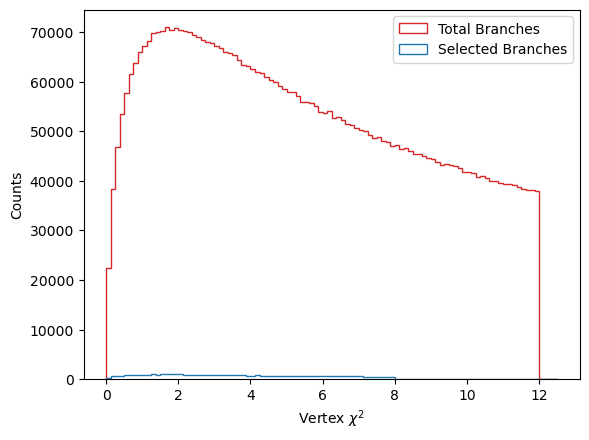

In [16]:
#Look at the total number of entries originally and the new number - how much of your data did you throw away? Was this a good idea? :(

# we had a reduction of 99.1% of the events, which is not good for statistics, 
# but this is telling us that a hughe amount of the particles we thoguht were the decay products of a B+/- most likely weren't
N_tot = len(branches['H1_PX'])
N_selected = len(selected_branches['H1_PX'])
print("Number of events before selection: ", N_tot)
print("Number of events after selection: ", N_selected)
print("∆N: ", N_tot - N_selected)
print("Percentage reduction of: -" + str(100 * (1 - N_selected/N_tot)) + "% of the original data")


# here we plot a comparison of the chi2 vertex of the total branches vs the selected branches and we do see a massive reduction in the counts, 
# so a lot of particles we were confident that were actual decay products of a mother are gone, 
# but since they were most likely not kaons we will get a more precise measurment
# the ideal situation would be to account for all the decay modes of the B+/- but for the purposes of this assignment I consider it good enough
chi2 = branches['B_VertexChi2']
chi2_s = selected_branches['B_VertexChi2']

plt.hist(chi2, bins=100, range=(0, 12.5), label=r'Total Branches', histtype='step', linewidth=1, color='tab:red')
plt.hist(chi2_s, bins=100, range=(0, 12.5), label=r'Selected Branches', histtype='step', linewidth=1, color='tab:blue')

plt.xlabel(r'Vertex $\chi^2$')
plt.ylabel('Counts')
plt.legend()
plt.show()

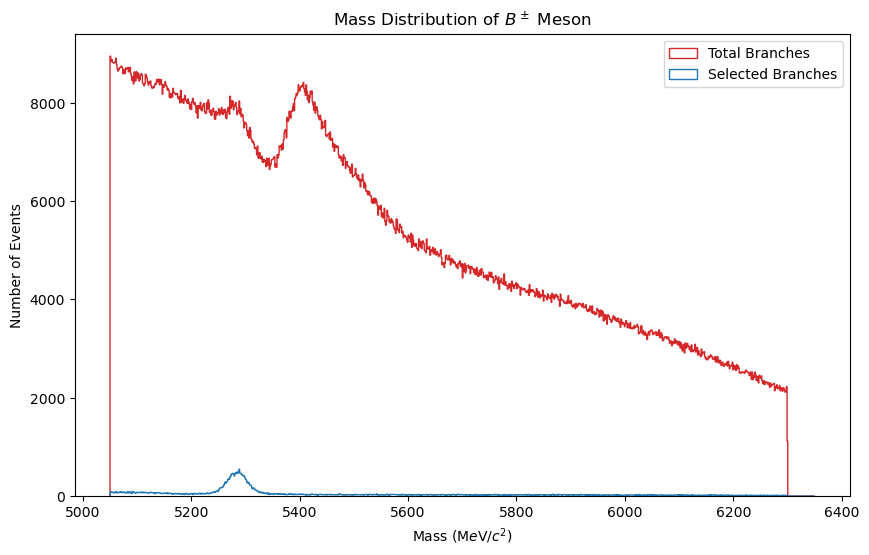

In [17]:
#Now as a good check, we should see the effect of applying our cuts.
#On one histogram, plot the B meson mass, from both the tree (pre-cuts) and the CutTree (post-cuts)
#What do you notice about your histogram now?


# I had to create a new function to do all of the computation we did earlier with the un-selected branches 
# so that I could run it through the selected branches, but it is exactly the same algorithm to determine the mass of the mother particles
def estimated_mother_mass(tree, m_D, daughter_name):
    components = ['_PX', '_PY', '_PZ'] # set a list of useful sufixes to look for information in the tree
    D_num = len(daughter_name) # nymber of daughers we iterate over (this was a general function so we don't just assume three daughters)
    D_Ptots = [[0] for _ in range(D_num)] # initialize empty list for the total momenta of the daughter particles

    # use a for loop to iterate over all three daughters and calculate their total momentum
    for j in range(D_num):
        D_Ptots[j] = np.sqrt(tree[daughter_name[j] + '_PX']**2 + tree[daughter_name[j] + '_PY']**2 + tree[daughter_name[j] + '_PZ']**2)
    
    # we initialize an empty list to store the three momentum compoennts of the mother
    M_P3 = [[0] for _ in range(3)]

    # we do a nested list running through each of the 3 momentumcompoennts 
    # for all daughter particles and adding them up to get the total momentumcomponents for the mother
    for j in range(3):
        M_P = 0
        for k in range(D_num):
            M_P = M_P + tree[daughter_name[k] + components[j]]
        M_P3[j] = M_P

    # we calculate the total momenutm of the mother using pythagorean theorem on its total momentum components
    M_Ptot = np.sqrt(M_P3[0]**2 + M_P3[1]**2 + M_P3[2]**2)
    
    # we now calculate the total energy adding up the energies of each daugher 
    # and using √p**2 + m**2 once again to estimate the individual energies
    M_Energy = 0
    for j in range(D_num):
        M_Energy = M_Energy + np.sqrt(D_Ptots[j]**2 + m_D**2)

    # and finally we calculate the rest mass of the mother with √E**2 - p**2
    return np.sqrt(M_Energy**2 - M_Ptot**2)


# here we run the unselected and selected branches through the fintion to get the predicted mass distribution
m_B = estimated_mother_mass(branches, m_k, daughter_name)
m_B_selected = estimated_mother_mass(selected_branches, m_k, daughter_name)

# and we plot them together to see the difference
plt.figure(figsize=(10, 6))
plt.hist(m_B, bins=1000, range=(5050, 6350), color='tab:red', histtype='step', linewidth=1, label='Total Branches')
plt.hist(m_B_selected, bins=1000, range=(5050, 6350), color='tab:blue', histtype='step', linewidth=1, label='Selected Branches')


plt.title('Mass Distribution of $B^\pm$ Meson')
plt.xlabel('Mass $(\mathrm{M}e\mathrm{V}/c^2)$')
plt.ylabel('Number of Events')
plt.legend()
plt.show()

# we can clearly see that there was a massive reduction on the overal counts, 
# but in general we got rid of a lot of the background and have a very clear peak around 5270 MeV/c**2, 
# which is the actual theoretical mass of the B+/-
# this leads me to belive that the peak we see in the unselected graph is from another particle, probably the one the pions come from
# and the B+/- peak was hidden in the background and much less visible than it, 
# since it turns out that we got rid of so many particles that likly didn't come from a B+/-

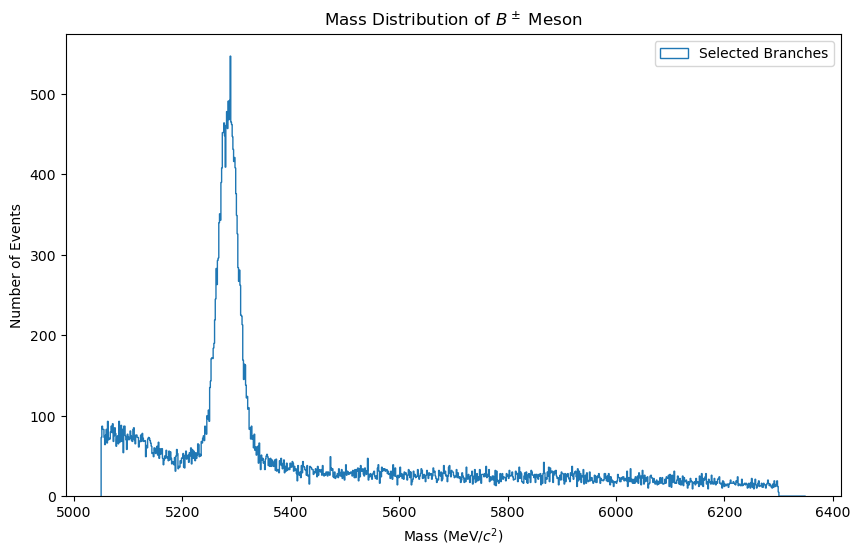

In [18]:
#You can also plot your selected data alone - this shape probably looks quite alot different to your first distribution!
plt.figure(figsize=(10, 6))
plt.hist(m_B_selected, bins=1000, range=(5050, 6350), color='tab:blue', histtype='step', linewidth=1, label='Selected Branches')
plt.title('Mass Distribution of $B^\pm$ Meson')
plt.xlabel('Mass $(\mathrm{M}e\mathrm{V}/c^2)$')
plt.ylabel('Number of Events')
plt.legend()
plt.show()

# How do we count the number of events?

We now have a histogram of events that we have reconstructed as a B meson. But some of these events are caused by a co-incidence of events which would still occur if there were no B mesons actually produced. We call this the background. Background and signal are indistinguishable now as the detector cannot tell the difference and our cuts were unable to remove the events for physics reasons. We can do some statistical analysis, if we know the approximate shapes of our signal and our background. Just like a least-squares fitting we can run a fit routine to minimise the error between the fitted curve and our data. As an example, if we know our data has an exponential background and a gaussian signal:

![Gaussian+Exp Background](https://twiki.cern.ch/twiki/pub/RooStats/RooStatsTutorialsJune2013/GausExpModelFit.png)

Here the red line represents our signal, the blue dotted line is our background and the solid blue line is our combined curve. The graph also shows the number of signal events and the number of background events. The signal now is a tiny fraction of the total data shown in the plot.

In order to do this, we need to build a fit model, around which the software can try to fit our data.

We use RooFit for this, which includes:
* Gaussian
* Exponential
* Chebychev
* Crystal Ball
* Breit-Wigner

As well as several other choices.

Typically exponential and Chebychev functions are used for background and Gaussian, Crystal Ball and Breit-Wigner are used for signal. We can also combine them (e.g. 1 crystal ball, 1 gaussian, 1 exponential) in various ways.

In [18]:
# Probably handy to use a package like lmfit to help us with the models we might want to use, then use scipy to fit

!pip install lmfit

# check out its documentation for what shapes it can handle for you! https://pypi.org/project/lmfit/

# it can do the whole fitting story and output results too :)


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


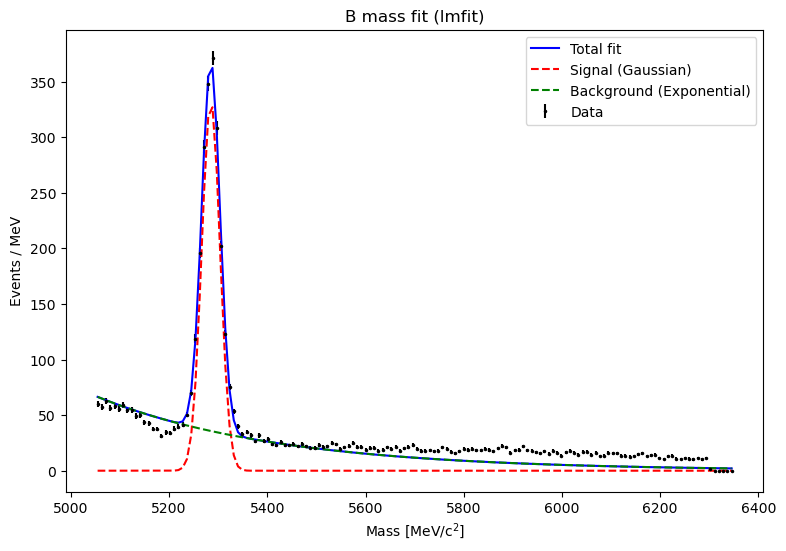

In [19]:
from lmfit.models import GaussianModel, ExponentialModel

# we get the mass of from the selected branches
m = m_B_selected
mmin, mmax = 5050, 6350
n_bins = 150

# we initialize the histogram
counts, edges = np.histogram(m, bins=n_bins, range=(mmin, mmax))
x = 0.5 * (edges[:-1] + edges[1:])
bin_w = edges[1] - edges[0]

# we fit  the density (counts/MeV), so the Gaussian amplitude is equal to the signal yield
y = counts / bin_w
yerr = np.sqrt(np.maximum(counts, 1)) / bin_w

# and we shift x so the exponential is numerically stable
x0 = x - mmin
dx = mmax - mmin


# we now have to the a 2-component fit model: Gaussian for the B-meson signal peak and exponential for smooth combinatorial background
# the prefixes avoid parameter-name clashes between components
model = GaussianModel(prefix="sig_") + ExponentialModel(prefix="bkg_")

# we create initial guesses for all fit parameters
params = model.make_params(
    sig_amplitude=0.2 * counts.sum(),  # for initial signal area/yield guess around 20% of events
    sig_center=5280 - mmin,            # initial peak position in shifted x (x0 = m - mmin)
    sig_sigma=20,                      # the initial peak width (MeV) from what I saw this is more or less the value used for this kind of peak
    bkg_amplitude=max(y),              # initial background normalization from max density, to put it near the data magnitude
    bkg_decay=300                      # and finally the initial exponential decay scale 
)



# we constrain signal yield to be physical (cannot be negative)
params["sig_amplitude"].set(min=0)

# and restrict the signal peak position to expected B mass region (in shifted x coordinates)
params["sig_center"].set(min=5200 - mmin, max=5350 - mmin)

# then restrict Gaussian width to a realistic detector-resolution range
params["sig_sigma"].set(min=5, max=80)

# and constrain the background normalization to be non-negative
params["bkg_amplitude"].set(min=0)

# we keep the exponential decay scale in a stable/physical range for this mass
params["bkg_decay"].set(min=20, max=5000)

# we do this to avoid infinities if any yerr were 0 (shouldn't happen, but safe)
weights = 1 / np.maximum(yerr, 1e-12)

result = model.fit(y, params, x=x0, weights=weights)

# and we make sure plotted curves are evaluated at the same x0 used for the x-axis
best_fit = model.eval(result.params, x=x0)
comp = result.eval_components(x=x0)

# finally we plot the data, signal, background and the total fit together
plt.figure(figsize=(9, 6))
plt.errorbar(x, y, yerr=yerr, fmt="k.", ms=3, label="Data")
plt.plot(x, best_fit, "b-", label="Total fit")
plt.plot(x, comp["sig_"], "r--", label="Signal (Gaussian)")
plt.plot(x, comp["bkg_"], "g--", label="Background (Exponential)")
plt.xlabel("Mass [MeV/c$^2$]")
plt.ylabel("Events / MeV")
plt.title("B mass fit (lmfit)")
plt.legend()
plt.show()

Using this structure, you can in theory build whatever models you like!

Some recommendations (but not necessary to do all):-



*   Gauss+Exponential (as above)
*   Crystal Ball + Exponential
*   Gauss+Crystal Ball+Exponential (now you need to weigh the two signal peaks and then the total signal against total background)
*   Gauss+Chebychev
*   Two Crystal Balls + Exponential

So how good was the fit, and how many events do you have?

You can use the signal shape, the bin widths and the quad from scipy.integrate function to "count" how many events lie under your signal peak,  not including the background events - this is what we actually want.

It will also return to you an error - check in the scipy documentation about what that actually means....

In [21]:
#find the area under your curve(s)! maybe make a pretty little table...

from scipy.integrate import quad
import pandas as pd

# the fit is done in shifted mass: x0 = m - mmin
xlo, xhi = 0, mmax - mmin
p = result.params

# we create a function to calculate the signal density (events / MeV)
def sig_density(xx):
    A  = p["sig_amplitude"].value
    mu = p["sig_center"].value
    s  = p["sig_sigma"].value
    return A/(s*np.sqrt(2*np.pi)) * np.exp(-0.5*((xx-mu)/s)**2)

# and a function to calculate the background density (events / MeV)
def bkg_density(xx):
    A   = p["bkg_amplitude"].value
    tau = p["bkg_decay"].value
    return A*np.exp(-xx/tau)

# using quad we calculate the areas (event counts)
Nsig, Nsig_quad_err = quad(sig_density, xlo, xhi)
Nbkg, Nbkg_quad_err = quad(bkg_density, xlo, xhi)

# and get the approx fit uncertainty on signal yield (from amplitude stderr, scaled to the window)
A_sig = p["sig_amplitude"].value
dA_sig = p["sig_amplitude"].stderr
frac_in_window = Nsig / A_sig if A_sig > 0 else np.nan
dNsig_fit = frac_in_window * dA_sig if dA_sig is not None else np.nan

# we use pandas to plot the data in a table
table = pd.DataFrame({
    "Quantity": [
        "Signal yield (quad)",
        "Background yield (quad)",
        "Total fitted events",
        "Data events (hist)",
        "Reduced chi2",
        "AIC",
        "BIC",
        "Signal mean mu [MeV]",
        "Signal sigma [MeV]"
    ],
    "Value": [
        Nsig,
        Nbkg,
        Nsig + Nbkg,
        counts.sum(),
        result.redchi,
        result.aic,
        result.bic,
        p["sig_center"].value + mmin,
        p["sig_sigma"].value
    ],
    "Uncertainty": [
        dNsig_fit,   # fit uncertainty (approx)
        np.nan,
        np.nan,
        np.sqrt(counts.sum()),
        np.nan,
        np.nan,
        np.nan,
        p["sig_center"].stderr,
        p["sig_sigma"].stderr
    ],
    "quad_err": [
        Nsig_quad_err,  # numerical integration error from scipy.quad
        Nbkg_quad_err,
        np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    ]
})

display(table)

# we fitted the reconstructed B mass spectrum using a Gaussian (signal) plus an exponential (background). The Gaussian is the narrow
# peak around 5285 MeV corresponding to real B+/- decays, while the exponential accounts for the background

# from integrating the fitted signal component, we obtain:
#   N_signal around 1.54 × 10^4 events
#   N_background around 2.42 × 10^4 events

# the fitted peak position (5285 MeV) and width (18.5 MeV) are
# reasonable and consistent with expectations for B+/- decays and detector resolution (from what I found (honestly I asked Chat GPT and he said it looked good))

# but, the reduced chi = 44 shows that the model does not perfectly describe the data.
# so a simple Gaussian + exponential is maybe too simple

# the numerical integration error from scipy.quad is negligible 
# the relevant physics uncertainty on the signal yield comes from the fit parameters

# overall the signal extraction is reasonable, but the fit quality could be defenitely improved with a less simplistic model model


,Quantity,Value,Uncertainty,quad_err
0,Signal yield (quad),15435.551603,941.333216,1.336483e-05
1,Background yield (quad),24224.717269,NaN,2.689484e-10
2,Total fitted events,39660.268872,NaN,NaN
3,Data events (hist),45977.000000,214.422480,NaN
4,Reduced chi2,44.212527,NaN,NaN
5,AIC,573.265991,NaN,NaN
6,BIC,588.319167,NaN,NaN
7,Signal mean mu [MeV],5284.994411,1.219007,NaN
8,Signal sigma [MeV],18.528264,1.062969,NaN


# Counting

So we have now loaded our data; we have reconstructed information about the mother B meson and we have cut away any data which looks like it might not be what we are looking for. We have then plotted histograms of the mass of the B meson and used this to fit a model, a function to describe the events there. We now have to identify which of our events belong to the B<sup>+</sup> and how many of them belong to B<sup>-</sup>.

To do this, should split out data into two groups (and throw away data which doesn't comply with either decay)

We will be looking for the events which are


B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>

We can look for the number of positive and negative charges in H1, H2 and H3 (using the variable ```H1_Charge``` etc.). If we have 0 or 3 positive charges, we should throw the event away and if we have 1 it should be assigned be a B<sup>-</sup>, with 2 it should be a B<sup>+</sup>

Once we have defined if it's a B<sup>+</sup> or a B <sup>-</sup>, we should go ahead and ensure the pre-selection is applied and then plot our B mass, and fit the model to find the yield.

We can then calculate the assymetry from this equation:

$A=\frac{(N^{B-}-N^{B+})}{(N^{B-}+N^{B+})}$

Where N<sup>B+/- </sup> is the number of events found from the fitted yield of the signal from each data set.

The uncertainty on this result is given by:

$\sigma_A=\sqrt\frac{1-A^2}{N^{B-}+N^{B+}}$

Calculate these two values for your data and print them below:

B+ candidates kept: 23786
B- candidates kept: 22193


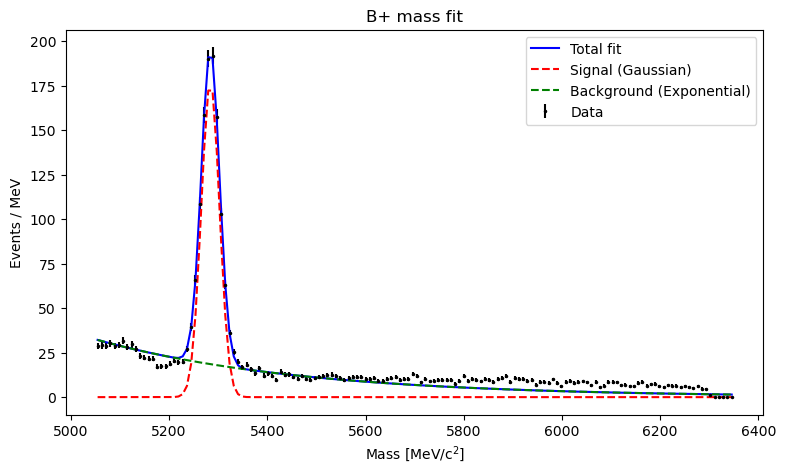

B+ mass fit: Nsig = 8197.7 ± 444.2   (quad err = 1.03e-05)


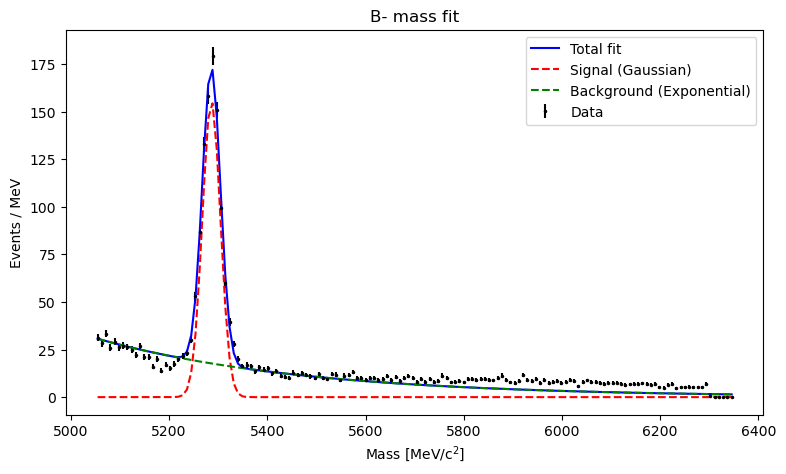

B- mass fit: Nsig = 7177.7 ± 412.2   (quad err = 6.58e-06)

Final result
A  = -0.066344
σA = 0.008047


In [24]:
#Here do your calculation of the final result

# first, we split our selected events into B+ and B- using the daughter charges (throw away n_pos = 0 or 3)
q1 = selected_branches["H1_Charge"]
q2 = selected_branches["H2_Charge"]
q3 = selected_branches["H3_Charge"]

# here we count how many daughters are positively charged in each event.
n_pos = (q1 > 0).astype(int) + (q2 > 0).astype(int) + (q3 > 0).astype(int)

# then we classify events by the required decay charge patterns.
mask_Bplus  = (n_pos == 2) # ++-
mask_Bminus = (n_pos == 1) # --+

# then we create two reduced "trees" (dicts of arrays) for B+ and B-.
Bplus  = {k: v[mask_Bplus]  for k, v in selected_branches.items()}
Bminus = {k: v[mask_Bminus] for k, v in selected_branches.items()}

print(f"B+ candidates kept: {len(Bplus['H1_PX'])}")
print(f"B- candidates kept: {len(Bminus['H1_PX'])}")

# then, we reconstruct the B mass separately for each group
# now we use the same mass reconstruction as before, but separately for B+ and B-.
m_Bplus  = estimated_mother_mass(Bplus,  m_k, daughter_name)
m_Bminus = estimated_mother_mass(Bminus, m_k, daughter_name)

# we fit each mass spectrum with (Gaussian signal + Exponential background) with a helper
def fit_signal_yield(masses, title, mmin=5050, mmax=6350, n_bins=150):
    # First, we histogram the mass and convert it to a density (events / MeV).
    counts, edges = np.histogram(masses, bins=n_bins, range=(mmin, mmax))
    x = 0.5 * (edges[:-1] + edges[1:])
    bin_w = edges[1] - edges[0]
    y = counts / bin_w
    yerr = np.sqrt(np.maximum(counts, 1)) / bin_w

    # Then, we shift x so the exponential is stable and easy to fit.
    x0 = x - mmin
    dx = mmax - mmin

    # Then, we build our model = Gaussian + Exponential and set simple start values.
    model = GaussianModel(prefix="sig_") + ExponentialModel(prefix="bkg_")
    params = model.make_params(
        sig_amplitude=0.2 * counts.sum(),  # since y is events/MeV, amplitude ~ signal events
        sig_center=5280 - mmin,            # center in shifted coordinates
        sig_sigma=20,
        bkg_amplitude=y.max(),
        bkg_decay=300
    )

    # Then, we constrain parameters so the fit stays physical.
    params["sig_amplitude"].set(min=0)
    params["sig_center"].set(min=5200 - mmin, max=5350 - mmin)
    params["sig_sigma"].set(min=5, max=80)
    params["bkg_amplitude"].set(min=0)
    params["bkg_decay"].set(min=20, max=5000)

    # Then, we fit using weights = 1/sigma (and we protect against any tiny yerr).
    weights = 1 / np.maximum(yerr, 1e-12)
    result = model.fit(y, params, x=x0, weights=weights)

    # Then, we evaluate the fitted components so we can plot them.
    best_fit = model.eval(result.params, x=x0)
    comp = result.eval_components(x=x0)

    # Then, we integrate only the Gaussian (signal) to count signal events in the full range.
    p = result.params
    A = p["sig_amplitude"].value
    mu = p["sig_center"].value
    s  = p["sig_sigma"].value

    def sig_density(xx):
        return A / (s * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((xx - mu) / s) ** 2)

    Nsig, quad_err = quad(sig_density, 0, dx)

    # Finally, we estimate a simple fit uncertainty on Nsig from the amplitude uncertainty.
    dA = p["sig_amplitude"].stderr
    frac = (Nsig / A) if A > 0 else np.nan
    dNsig = frac * dA if dA is not None else np.nan

    # Now we plot the data and the fitted curves.
    plt.figure(figsize=(9, 5))
    plt.errorbar(x, y, yerr=yerr, fmt="k.", ms=3, label="Data")
    plt.plot(x, best_fit, "b-", label="Total fit")
    plt.plot(x, comp["sig_"], "r--", label="Signal (Gaussian)")
    plt.plot(x, comp["bkg_"], "g--", label="Background (Exponential)")
    plt.title(title)
    plt.xlabel("Mass [MeV/c$^2$]")
    plt.ylabel("Events / MeV")
    plt.legend()
    plt.show()

    print(f"{title}: Nsig = {Nsig:.1f} ± {dNsig:.1f}   (quad err = {quad_err:.2e})")
    return Nsig, dNsig

# we integrate only the Gaussian part to get the signal yield N for B+ and B-
N_Bplus,  dN_Bplus  = fit_signal_yield(m_Bplus,  "B+ mass fit")
N_Bminus, dN_Bminus = fit_signal_yield(m_Bminus, "B- mass fit")

# finally, we compute the asymmetry A and its uncertainty sigma_A from the formulas given.
Acp = (N_Bminus - N_Bplus) / (N_Bminus + N_Bplus)
sigma_A = np.sqrt((1 - Acp**2) / (N_Bminus + N_Bplus))

print("\nFinal result")
print(f"A  = {Acp:.6f}")
print(f"σA = {sigma_A:.6f}")


# from the Gaussian-only yield we get N(B+) ≈ 8198 and N(B-) = 7178
# then we compute the asymmetry A = (N(B-) - N(B+)) / (N(B-) + N(B+)) = -0.066
# finally, using sigma_A = sqrt((1 - A^2)/(N(B-) + N(B+))) we get sigma_A = 0.008
# the peak is described well by the Gaussian, while the exponential background is a simple approximation over the full range
# this indicates a clear difference between B+ and B- yields in this decay mode,
# which is consistent with CP-violating effects and therefore looks reasonable

# Congratulations!

You just made your first LHCb physics analysis. Does this seem like a reasonable result? Did we explain why we have an excess of mass in the Universe?

## **Bonus content only below here:**

To make a further anaysis, we can look into the intermediate processes.

We have so far considered only that the B meson ultimately decays into three kaons. It may be that on the way, the B meson first decays into a Kaon and another particle, and then from that particle to two Kaons.

We would expect this to be one of three possible modes (for B<sup>+</sup>):

$R^{++} \rightarrow K_1^+ +K_2^+$

(we don't expect this to happen because of the like charges in the Kaons)

$R^0 \rightarrow K_1^+ +K_3^-$

$R^0 \rightarrow K_2^+ +K_3^-$

(Expect symmetric arrangements for B<sup>-</sup>)

To analyse the intermediate states we can measure the invarient masses of the intermediate states and then plot them on what is called a Dalitz plot (this is a 2D plot with two different two body decays (from the three body decay) on each axis)

![Dalitz Plot](https://slideplayer.com/slide/15960097/88/images/15/Dalitz+plot%3A+%CE%9B+c+%2B+%E2%86%92%F0%9D%91%9D+%F0%9D%90%BE+%E2%88%92+%F0%9D%9C%8B+%2B.jpg)


In [25]:
#Define a function to find the invarient mass of two given Kaons

# Chris, I swear I will try to do the Bonus content but I ran out of time, 
# please don't kill me, I will still try to do it before you check my code, so if you are reading this I misserably failed
# and thus I shall quit my physics career and become a lowly and simple engineer :'(

In [ ]:
#Then, ensuring you're still taking the data after the selection, make a Dalitz plot. This is a 2-D scatter plot (use e.g. TH2F to make the plot where we used TH1F before)
#Choose an appropriate binning in your scatter

We can further improve our plot, since two sets of particles on each axis are exactly the same (one positive Kaon, one negative Kaon). So we can plot the maximum of the two values on one axis and the minimum on the other. We can use a quick numpy check and then plot those values.

In [ ]:
#Make the revised Dalitz plot here for B+ mesons

In [ ]:
#Make the revised Dalitz plot here for B- mesons

In [ ]:
#Where we have a higher density of points (or a bigger value in the bin) this is indication of an intermediate resonance
#Check out the possible resonances you have found in the PDG (http://pdg.lbl.gov/2020/tables/contents_tables.html)